# Random Forest Experiments
This notebook is a lightweight sandbox for primitive test runs using Random Forest.
Run cells in order from top to bottom.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
import joblib

BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "reply_count", "favorite_count", "num_urls", "num_mentions"
]

RF_PARAMS = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))
print("Random Forest params:", RF_PARAMS)

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9
Random Forest params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


In [2]:
def resolve_users_csv(base_dir, dataset_entry):
    """Resolve dataset entry to a users.csv path."""
    candidates = [
        os.path.join(base_dir, dataset_entry),
        os.path.join(base_dir, dataset_entry, USERS_FILE),
        os.path.join(base_dir, dataset_entry, dataset_entry, USERS_FILE),
    ]
    for path in candidates:
        if os.path.isfile(path):
            return path
    return None


def load_all_data(dataset_map, base_dir):
    """Load all configured datasets and attach binary labels."""
    frames = []
    missing_files = []

    for dataset_entry, label in dataset_map.items():
        path = resolve_users_csv(base_dir, dataset_entry)
        if path is None:
            missing_files.append(dataset_entry)
            continue

        df = pd.read_csv(
            path,
            encoding="utf-8",
            on_bad_lines="skip",
            low_memory=False,
        )
        df["label"] = int(label)
        df["source_file"] = dataset_entry
        frames.append(df)
        print(f"Loaded {dataset_entry}: {len(df):,} rows")

    if missing_files:
        print("\nMissing dataset entries:")
        for entry in missing_files:
            print("-", entry)

    if not frames:
        raise ValueError("No dataset files were loaded. Check BASE_DIR and DATASETS.")

    all_data = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows loaded: {len(all_data):,}")
    return all_data


def load_tweets(base_dir, dataset_entry):
    """Load and aggregate tweet-level features per user."""
    candidates = [
        os.path.join(base_dir, dataset_entry, "tweets.csv"),
        os.path.join(base_dir, dataset_entry, dataset_entry, "tweets.csv"),
    ]

    for path in candidates:
        if os.path.isfile(path):
            available = ["user_id"] + TWEET_FEATURES
            chunks = []
            for chunk in pd.read_csv(
                path,
                usecols=lambda c: c in available,
                chunksize=100_000,
                encoding="utf-8",
                on_bad_lines="skip",
            ):
                chunks.append(chunk)

            dataframe = pd.concat(chunks, ignore_index=True)
            agg_cols = [c for c in TWEET_FEATURES if c in dataframe.columns]
            dataframe[agg_cols] = dataframe[agg_cols].apply(pd.to_numeric, errors="coerce")
            agg_cols = [c for c in agg_cols if pd.api.types.is_numeric_dtype(dataframe[c])]

            if not agg_cols:
                return None

            return dataframe.groupby("user_id")[agg_cols].mean().reset_index()

    return None

In [3]:
# Block 1: Data loading (full configured datasets)
raw = load_all_data(DATASETS, BASE_DIR)

tweet_aggs = []
for dataset_entry in DATASETS:
    agg = load_tweets(BASE_DIR, dataset_entry)
    if agg is not None:
        tweet_aggs.append(agg)

if tweet_aggs:
    all_tweets = pd.concat(tweet_aggs, ignore_index=True)
    if "id" in raw.columns:
        raw = raw.rename(columns={"id": "user_id"})
    raw = raw.merge(all_tweets, on="user_id", how="left")

print("Raw data shape:", raw.shape)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368
Raw data shape: (14368, 48)


In [4]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X = raw[available_numeric].copy()
X = X.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X = pd.concat([X, raw[tweet_features]], axis=1)
X = X.fillna(0)

print("Features:", list(X.columns))
print("Shape:", X.shape)

y = raw["label"].astype(int)

if "user_id" in raw.columns:
    group_key = raw["user_id"].astype(str)
else:
    group_key = raw.index.astype(str)

if "source_file" in raw.columns:
    group_key = raw["source_file"].astype(str) + "::" + group_key

from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    np.arange(len(X)), test_size=0.2, stratify=y, random_state=42
)
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train = group_key.iloc[train_idx]
groups_test = group_key.iloc[test_idx]
group_overlap = len(set(groups_train) & set(groups_test))

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_ratio = neg_count / pos_count if pos_count else 1.0

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Group overlap train/test (should be 0):", group_overlap)
print("Class balance:\n", y.value_counts(dropna=False))
print(f"Train class ratio (neg/pos): {class_ratio:.4f}")

Features: ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'verified', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions']
Shape: (14368, 12)
Train shape: (11494, 12)
Test shape: (2874, 12)
Group overlap train/test (should be 0): 0
Class balance:
 label
1    10894
0     3474
Name: count, dtype: int64
Train class ratio (neg/pos): 0.3189


In [5]:
# Block 3: Training and cross-validated benchmarking
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# remove groups=group_key from both cross_validate() calls

baseline = DummyClassifier(strategy="most_frequent")
baseline_scores = cross_validate(
    baseline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

rf_cv_scores = cross_validate(
    RandomForestClassifier(**RF_PARAMS),
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

print("\n5-fold group cross-validation")
for metric_name in scoring:
    baseline_values = baseline_scores[f"test_{metric_name}"]
    model_values = rf_cv_scores[f"test_{metric_name}"]
    print(
        f"{metric_name:>18}: baseline {baseline_values.mean():.4f} ± {baseline_values.std():.4f} | "
        f"random forest {model_values.mean():.4f} ± {model_values.std():.4f}"
    )

model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)

print("\nTraining complete.")
print("Number of trees:", len(model.estimators_))
print("OOB score available:", hasattr(model, "oob_score_") and getattr(model, "oob_score_", None) is not None)


5-fold group cross-validation
          accuracy: baseline 0.7582 ± 0.0001 | random forest 0.9944 ± 0.0020
 balanced_accuracy: baseline 0.5000 ± 0.0000 | random forest 0.9917 ± 0.0029
          f1_macro: baseline 0.4312 ± 0.0000 | random forest 0.9923 ± 0.0027
           roc_auc: baseline 0.5000 ± 0.0000 | random forest 0.9998 ± 0.0001
 average_precision: baseline 0.7582 ± 0.0001 | random forest 0.9999 ± 0.0000

Training complete.
Number of trees: 300
OOB score available: False


Holdout metrics
          accuracy: 0.9937
 balanced_accuracy: 0.9895
          f1_macro: 0.9914
           roc_auc: 0.9998
             auprc: 0.9999
     precision_bot: 0.9941
        recall_bot: 0.9977


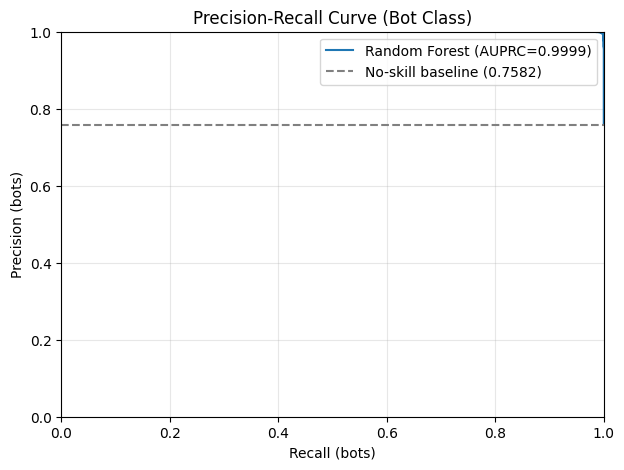


Baseline on same holdout
          accuracy: 0.7582
 balanced_accuracy: 0.5000
          f1_macro: 0.4312
     precision_bot: 0.7582
        recall_bot: 1.0000

Confusion Matrix:
[[ 682   13]
 [   5 2174]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9813    0.9870       695
           1     0.9941    0.9977    0.9959      2179

    accuracy                         0.9937      2874
   macro avg     0.9934    0.9895    0.9914      2874
weighted avg     0.9937    0.9937    0.9937      2874


Top 10 features by importance:


,feature,importance
3,favourites_count,0.396865
0,statuses_count,0.239339
1,followers_count,0.088855
11,num_mentions,0.086181
9,favorite_count,0.071783
10,num_urls,0.058172
2,friends_count,0.026461
4,listed_count,0.022667
8,reply_count,0.005427
5,default_profile,0.003487



Per-source holdout summary:


,source_file,true_label,support,accuracy,avg_pred_proba,predicted_bot_rate
1,genuine_accounts.csv,0,695,0.981295,0.026317,0.018705
2,social_spambots_1.csv,1,207,1.000000,0.997198,1.000000
3,social_spambots_2.csv,1,681,1.000000,0.999868,1.000000
4,social_spambots_3.csv,1,83,1.000000,0.993815,1.000000
5,traditional_spambots_1.csv,1,210,1.000000,0.997873,1.000000
6,traditional_spambots_2.csv,1,21,1.000000,0.961746,1.000000
8,traditional_spambots_4.csv,1,230,1.000000,0.997362,1.000000
0,fake_followers.csv,1,677,0.998523,0.997415,0.998523
7,traditional_spambots_3.csv,1,70,0.942857,0.881667,0.942857


In [6]:
# Block 4: Evaluation
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]
bot_precision = precision_score(y_test, pred, pos_label=1, zero_division=0)
bot_recall = recall_score(y_test, pred, pos_label=1, zero_division=0)
auprc = average_precision_score(y_test, pred_proba)
pr_precision_curve, pr_recall_curve, _ = precision_recall_curve(y_test, pred_proba)

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "f1_macro": f1_score(y_test, pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, pred_proba),
    "auprc": auprc,
    "precision_bot": bot_precision,
    "recall_bot": bot_recall,
}

print("Holdout metrics")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name:>18}: {metric_value:.4f}")

baseline_bot_rate = y_test.mean()
plt.figure(figsize=(7, 5))
plt.plot(pr_recall_curve, pr_precision_curve, label=f"Random Forest (AUPRC={auprc:.4f})")
plt.hlines(
    y=baseline_bot_rate,
    xmin=0,
    xmax=1,
    colors="gray",
    linestyles="--",
    label=f"No-skill baseline ({baseline_bot_rate:.4f})",
)
plt.xlabel("Recall (bots)")
plt.ylabel("Precision (bots)")
plt.title("Precision-Recall Curve (Bot Class)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("\nBaseline on same holdout")
print(f"{'accuracy':>18}: {accuracy_score(y_test, baseline_pred):.4f}")
print(f"{'balanced_accuracy':>18}: {balanced_accuracy_score(y_test, baseline_pred):.4f}")
print(f"{'f1_macro':>18}: {f1_score(y_test, baseline_pred, average='macro'):.4f}")
print(f"{'precision_bot':>18}: {precision_score(y_test, baseline_pred, pos_label=1, zero_division=0):.4f}")
print(f"{'recall_bot':>18}: {recall_score(y_test, baseline_pred, pos_label=1, zero_division=0):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_,
})
importance_df = importance_df.sort_values("importance", ascending=False)

print("\nTop 10 features by importance:")
display(importance_df.head(10))

if "source_file" in raw.columns:
    test_results = pd.DataFrame(
        {
            "source_file": raw.loc[X_test.index, "source_file"].values,
            "true_label": y_test.values,
            "pred_label": pred,
            "pred_proba": pred_proba,
        },
        index=X_test.index,
    )
    test_results["correct"] = test_results["true_label"] == test_results["pred_label"]
    source_summary = (
        test_results.groupby(["source_file", "true_label"], as_index=False)
        .agg(
            support=("correct", "size"),
            accuracy=("correct", "mean"),
            avg_pred_proba=("pred_proba", "mean"),
            predicted_bot_rate=("pred_label", "mean"),
        )
        .sort_values(["true_label", "accuracy"], ascending=[True, False])
    )
    print("\nPer-source holdout summary:")
    display(source_summary)

In [7]:
# 1) PR baseline
print("Bot prevalence in test (PR no-skill baseline):", y_test.mean())

# 2) Repeated shuffle-label sanity check
rng = np.random.default_rng(42)
shuffle_auprcs = []
for _ in range(20):
    y_train_shuf = pd.Series(rng.permutation(y_train.values), index=y_train.index)
    shuf_model = RandomForestClassifier(**RF_PARAMS).fit(X_train, y_train_shuf)
    shuf_proba = shuf_model.predict_proba(X_test)[:, 1]
    shuffle_auprcs.append(average_precision_score(y_test, shuf_proba))
print("Shuffled-label AUPRC mean ± std:", f"{np.mean(shuffle_auprcs):.4f} ± {np.std(shuffle_auprcs):.4f}")

# 3) Exact duplicate feature rows crossing split
train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)
overlap = np.intersect1d(train_hash.values, test_hash.values).size
print("Exact duplicate X rows shared across train/test:", overlap)


Bot prevalence in test (PR no-skill baseline): 0.7581767571329158
Shuffled-label AUPRC mean ± std: 0.7991 ± 0.0116
Exact duplicate X rows shared across train/test: 7


## Secondary Analysis: Leave-One-Bot-Out (LOBO)
LOBO is a generalization stress-test run on top of the primary 80/20 results.
Each bot family is withheld entirely from training to test cross-family generalization.
It holds out one bot source at a time and reports macro and weighted summaries.

LOBO results (each row: hold out one bot source; test includes fixed genuine holdout + held-out bot source):


,held_out_bot_source,test_rows,bot_support,genuine_support,bot_prevalence,auprc,precision_bot,recall_bot,accuracy,balanced_accuracy
0,traditional_spambots_3.csv,1098,403,695,0.367031,0.882648,0.977099,0.317618,0.746812,0.656651
1,traditional_spambots_2.csv,795,100,695,0.125786,0.986049,0.977273,0.860000,0.979874,0.928561
2,fake_followers.csv,4046,3351,695,0.828225,0.999057,0.998720,0.698299,0.749382,0.846991
3,traditional_spambots_4.csv,1823,1128,695,0.618760,0.999727,0.998209,0.988475,0.991772,0.992799
4,social_spambots_3.csv,1159,464,695,0.400345,0.999918,0.993562,0.997845,0.996549,0.996764
5,social_spambots_2.csv,4152,3457,695,0.832611,1.000000,0.999133,1.000000,0.999277,0.997842
6,social_spambots_1.csv,1686,991,695,0.587782,1.000000,0.996982,1.000000,0.998221,0.997842
7,traditional_spambots_1.csv,1695,1000,695,0.589971,1.000000,0.997009,1.000000,0.998230,0.997842



LOBO macro-average (mean ± std) across held-out bot sources:
             auprc: 0.9834 ± 0.0410
     precision_bot: 0.9922 ± 0.0095
        recall_bot: 0.8578 ± 0.2434
          accuracy: 0.9325 ± 0.1140
 balanced_accuracy: 0.9269 ± 0.1217

LOBO weighted-average (by test_rows) across held-out bot sources:
             auprc: 0.9912
     precision_bot: 0.9956
        recall_bot: 0.8721
          accuracy: 0.9188
 balanced_accuracy: 0.9340

Hardest held-out source by AUPRC:
traditional_spambots_3.csv | AUPRC=0.8826, Precision_bot=0.9771, Recall_bot=0.3176, BalancedAcc=0.6567


<Figure size 1000x500 with 0 Axes>

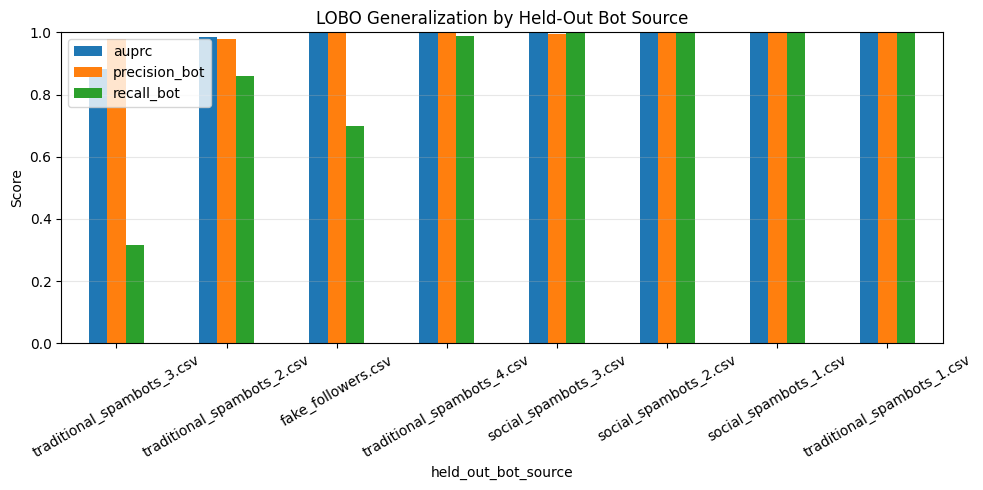

In [8]:
# Block 8: Leave-one-bot-source-out (LOBO) evaluation with fixed genuine holdout (report-grade)
# LOBO is a secondary generalization analysis — primary results use the 80/20 stratified split above.
# LOBO tests whether RF generalizes to entirely unseen bot families.

if "source_file" not in raw.columns:
    raise ValueError("source_file column is required for LOBO evaluation.")

entity_key = (
    raw["source_file"].astype(str) + "::" +
    (raw["user_id"].astype(str) if "user_id" in raw.columns else raw.index.astype(str))
)

genuine_source = "genuine_accounts.csv"
genuine_mask = raw["source_file"] == genuine_source
if genuine_mask.sum() == 0:
    raise ValueError(f"No rows found for {genuine_source}.")

genuine_idx = raw.index[genuine_mask].to_numpy()
genuine_groups = entity_key.loc[genuine_idx]

gss_genuine = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
genuine_train_rel, genuine_test_rel = next(
    gss_genuine.split(X.loc[genuine_idx], y.loc[genuine_idx], groups=genuine_groups)
)
genuine_train_idx = genuine_idx[genuine_train_rel]
genuine_test_idx = genuine_idx[genuine_test_rel]

bot_sources = sorted(
    [
        source for source, label in DATASETS.items()
        if label == 1 and (raw["source_file"] == source).any()
    ]
)

lobo_rows = []
for held_out_bot_source in bot_sources:
    held_out_bot_idx = raw.index[raw["source_file"] == held_out_bot_source].to_numpy()
    train_bot_idx = raw.index[(raw["label"] == 1) & (raw["source_file"] != held_out_bot_source)].to_numpy()

    train_idx = np.concatenate([genuine_train_idx, train_bot_idx])
    test_idx = np.concatenate([genuine_test_idx, held_out_bot_idx])

    X_lobo_train = X.loc[train_idx]
    y_lobo_train = y.loc[train_idx]
    X_lobo_test = X.loc[test_idx]
    y_lobo_test = y.loc[test_idx]

    lobo_model = RandomForestClassifier(**RF_PARAMS)
    lobo_model.fit(X_lobo_train, y_lobo_train)

    lobo_pred = lobo_model.predict(X_lobo_test)
    lobo_proba = lobo_model.predict_proba(X_lobo_test)[:, 1]

    lobo_rows.append(
        {
            "held_out_bot_source": held_out_bot_source,
            "test_rows": int(len(test_idx)),
            "bot_support": int((y_lobo_test == 1).sum()),
            "genuine_support": int((y_lobo_test == 0).sum()),
            "bot_prevalence": float(y_lobo_test.mean()),
            "auprc": average_precision_score(y_lobo_test, lobo_proba),
            "precision_bot": precision_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
            "recall_bot": recall_score(y_lobo_test, lobo_pred, pos_label=1, zero_division=0),
            "accuracy": accuracy_score(y_lobo_test, lobo_pred),
            "balanced_accuracy": balanced_accuracy_score(y_lobo_test, lobo_pred),
        }
    )

lobo_results = pd.DataFrame(lobo_rows).sort_values("auprc", ascending=True).reset_index(drop=True)

print("LOBO results (each row: hold out one bot source; test includes fixed genuine holdout + held-out bot source):")
display(lobo_results)

summary_cols = ["auprc", "precision_bot", "recall_bot", "accuracy", "balanced_accuracy"]
macro_mean = lobo_results[summary_cols].mean()
macro_std = lobo_results[summary_cols].std()
weights = lobo_results["test_rows"] / lobo_results["test_rows"].sum()
weighted_mean = (lobo_results[summary_cols].multiply(weights, axis=0)).sum(axis=0)

print("\nLOBO macro-average (mean ± std) across held-out bot sources:")
for metric in summary_cols:
    print(f"{metric:>18}: {macro_mean[metric]:.4f} ± {macro_std[metric]:.4f}")

print("\nLOBO weighted-average (by test_rows) across held-out bot sources:")
for metric in summary_cols:
    print(f"{metric:>18}: {weighted_mean[metric]:.4f}")

hardest = lobo_results.sort_values("auprc", ascending=True).iloc[0]
print("\nHardest held-out source by AUPRC:")
print(
    f"{hardest['held_out_bot_source']} | "
    f"AUPRC={hardest['auprc']:.4f}, Precision_bot={hardest['precision_bot']:.4f}, "
    f"Recall_bot={hardest['recall_bot']:.4f}, BalancedAcc={hardest['balanced_accuracy']:.4f}"
)

report_summary = {
    "primary_eval": "LOBO",
    "macro_mean": {k: float(v) for k, v in macro_mean.items()},
    "macro_std": {k: float(v) for k, v in macro_std.items()},
    "weighted_mean": {k: float(v) for k, v in weighted_mean.items()},
    "hardest_source": str(hardest["held_out_bot_source"]),
}

plt.figure(figsize=(10, 5))
plot_df = lobo_results.set_index("held_out_bot_source")[["auprc", "precision_bot", "recall_bot"]]
plot_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1), rot=30)
plt.title("LOBO Generalization by Held-Out Bot Source")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Block 5: Feature importance list
importance_sorted = importance_df.sort_values("importance", ascending=False)

print("Top 10 Features — Random Forest:")
for i, row in enumerate(importance_sorted.head(10).itertuples(index=False), 1):
    print(f"  {i:2}. {row.feature:<30} {row.importance:.4f}")

Top 10 Features — Random Forest:
   1. favourites_count               0.3969
   2. statuses_count                 0.2393
   3. followers_count                0.0889
   4. num_mentions                   0.0862
   5. favorite_count                 0.0718
   6. num_urls                       0.0582
   7. friends_count                  0.0265
   8. listed_count                   0.0227
   9. reply_count                    0.0054
  10. default_profile                0.0035


In [10]:
# Block 6: Save model
MODEL_PATH = "random_forest_bot_detector.joblib"
joblib.dump(model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to random_forest_bot_detector.joblib
